# Context-Free Grammars and Constituency Parsing


In [38]:
# Import the Natural Language Toolkit
import nltk

# Define a Context-Free Grammar
# Non-terminals: S (Sentence), NP (Noun Phrase), VP (Verb Phrase), PP (Prepositional Phrase)
# Terminals: Actual words (e.g., 'I', 'shot', 'elephant')
grammar = nltk.CFG.fromstring("""
  S -> NP VP
  PP -> P NP
  NP -> Det N | Det N PP | 'I'
  VP -> V NP | VP PP
  Det -> 'an' | 'my'
  N -> 'elephant' | 'pajamas'
  V -> 'shot'
  P -> 'in'
""")

print("Grammar defined successfully!")
print("Here are the productions in our grammar:")
for production in grammar.productions():
    print("  ", production)

Grammar defined successfully!
Here are the productions in our grammar:
   S -> NP VP
   PP -> P NP
   NP -> Det N
   NP -> Det N PP
   NP -> 'I'
   VP -> V NP
   VP -> VP PP
   Det -> 'an'
   Det -> 'my'
   N -> 'elephant'
   N -> 'pajamas'
   V -> 'shot'
   P -> 'in'


### Parsing the Sentence
Now that we have our grammar, we can build a parser. We will use a `ChartParser` which is an implementation of dynamic programming parsing algorithms (like the CKY algorithm discussed in Chapter 18).

Because our sentence is structurally ambiguous (did *I* have the pajamas on, or did the *elephant* have them on?), the parser should return multiple valid syntactic trees.

In [39]:
# Define the sentence as a list of words
sentence = "I shot an elephant in my pajamas".split()

# Create a Chart Parser using our grammar
parser = nltk.ChartParser(grammar)

# Parse the sentence and collect the resulting trees
trees = list(parser.parse(sentence))

print(f"Found {len(trees)} valid parse trees for the sentence!\n")

for i, tree in enumerate(trees):
    print(f"--- Parse Tree {i + 1} ---")
    print(tree)
    print()

Found 2 valid parse trees for the sentence!

--- Parse Tree 1 ---
(S
  (NP I)
  (VP
    (VP (V shot) (NP (Det an) (N elephant)))
    (PP (P in) (NP (Det my) (N pajamas)))))

--- Parse Tree 2 ---
(S
  (NP I)
  (VP
    (V shot)
    (NP (Det an) (N elephant) (PP (P in) (NP (Det my) (N pajamas))))))



### Visualizing the Trees
Reading bracketed text can be difficult. NLTK provides a way to draw the trees graphically. 

*(Note: Running `tree.draw()` typically opens a new window. If you are running this in Google Colab or want to see it inline, NLTK trees will often render automatically if placed at the end of a cell.)*

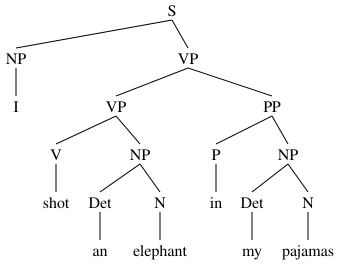

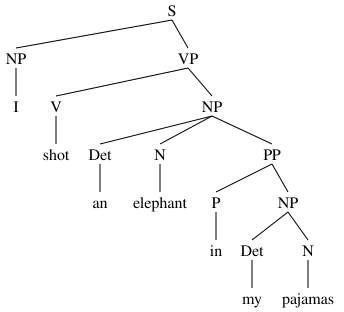

In [40]:
# Display the first tree
# If you are in a standard local Jupyter Notebook, tree.draw() opens a GUI window.
# If you are in Jupyter Lab, simply putting the variable at the end of the cell will render it.
display(trees[0])

# To see the second interpretation:
display(trees[1])

### What do the two trees mean?

1. **Tree 1 (VP Attachment):** The Prepositional Phrase (`PP -> in my pajamas`) is attached to the Verb Phrase (`VP`). This implies the action of shooting happened while *the speaker* was in their pajamas.
2. **Tree 2 (NP Attachment):** The Prepositional Phrase (`PP`) is attached directly to the Noun Phrase (`NP -> an elephant`). This implies that the *elephant itself* was wearing the pajamas.

This perfectly demonstrates why Context-Free Grammars are powerful: they don't just tell us if a sentence is grammatically valid; they provide the structural framework needed to extract semantic meaning!

### Example 2: Chomsky Normal Form (CNF)
Dynamic programming parsing algorithms, like the famous Cocke-Kasami-Younger (CKY) algorithm, require grammars to first be in Chomsky Normal Form (CNF). 

A context-free grammar is in CNF if each of its productions takes one of two forms:
1. $A \rightarrow B C$ (A non-terminal expands to exactly two non-terminals, also known as binary branching).
2. $A \rightarrow w$ (A non-terminal expands to exactly one terminal/word).

Restricting a grammar to CNF does not lead to any loss in expressiveness; any CFG can be converted into a corresponding CNF grammar. Let's look at how we can convert syntactic trees into CNF using NLTK.

In [41]:
# Let's take the first ambiguous tree from our ATIS example

sentence_exp4 = "I shot an elephant in my pajamas".split()

ambiguous_trees = list(parser.parse(sentence_exp4))

sample_tree = ambiguous_trees[1]

print("--- Original Tree ---")
print(sample_tree)
# print(f"Is it in CNF? {sample_tree.is_chomsky_normal_form()}\n")

# NLTK provides a built-in method to convert a tree to Chomsky Normal Form
# This process introduces dummy non-terminals (often using the '|' symbol or splitting nodes) 
# to ensure all branches are binary.
sample_tree.chomsky_normal_form()

print("--- Tree converted to CNF ---")
print(sample_tree)
# print(f"Is it in CNF now? {sample_tree.is_chomsky_normal_form()}")

# Note: In practice, converting a whole grammar to CNF involves eliminating 
# unit productions (e.g., A -> B) and rules that mix terminals and non-terminals.

--- Original Tree ---
(S
  (NP I)
  (VP
    (V shot)
    (NP (Det an) (N elephant) (PP (P in) (NP (Det my) (N pajamas))))))
--- Tree converted to CNF ---
(S
  (NP I)
  (VP
    (V shot)
    (NP
      (Det an)
      (NP|<N-PP> (N elephant) (PP (P in) (NP (Det my) (N pajamas)))))))


### Example 3: The ATIS Domain and Lexical Ambiguity
In conversational agents for flight booking (the ATIS domain), a word can serve multiple grammatical roles. For instance, the word "book" can be an ambiguous word: it acts as a Verb in "book that flight" and as a Noun in "hand me that book"[cite: 178]. 

Let's define a new grammar (the L1 miniature English grammar) that captures these rules and vocabulary[cite: 244].

In [42]:
# The L1 grammar includes rules for verb phrases (VP), noun phrases (NP), and prepositional phrases (PP)[cite: 244].
atis_grammar = nltk.CFG.fromstring("""
  S -> NP VP | Aux NP VP | VP
  NP -> Pronoun | ProperNoun | Det Nominal
  Nominal -> Noun | Nominal Noun | Nominal PP
  VP -> Verb | Verb NP | Verb NP PP | Verb PP | VP PP
  PP -> Preposition NP
  
  Det -> 'that' | 'this' | 'the' | 'a' | 'an'
  Noun -> 'book' | 'flight' | 'meal' | 'money' | 'morning'
  Verb -> 'book' | 'include' | 'prefer'
  Pronoun -> 'I' | 'she' | 'me'
  ProperNoun -> 'Houston' | 'United'
  Aux -> 'does'
  Preposition -> 'from' | 'to' | 'on' | 'near' | 'through'
""")

# We use a ChartParser because it relies on dynamic programming to efficiently handle structural ambiguities[cite: 308].
atis_parser = nltk.ChartParser(atis_grammar)
print("ATIS Grammar L1 defined!")

ATIS Grammar L1 defined!


Parsing:  I prefer a morning flight
(S
  (NP (Pronoun I))
  (VP
    (Verb prefer)
    (NP (Det a) (Nominal (Nominal (Noun morning)) (Noun flight)))))


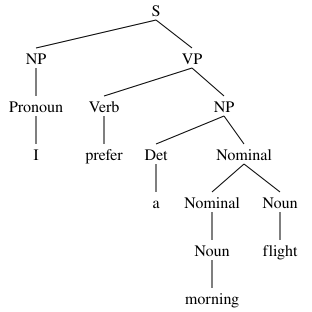

In [43]:
# Let's parse a straightforward request
sentence2 = "I prefer a morning flight".split()

print("Parsing: ", " ".join(sentence2))
for tree in atis_parser.parse(sentence2):
    print(tree)
    display(tree) # Will draw the tree inline in Jupyter Lab/Notebook

### Example 4: Prepositional Phrase (PP) Attachment Ambiguity
Structural ambiguity occurs when a grammar can assign more than one parse to a sentence. A very common type is **attachment ambiguity**, which happens if a particular constituent can be attached to the parse tree at more than one place.

Let's parse the sentence: **"book the flight through Houston"**. 
The prepositional phrase "through Houston" could attach to the *flight* (a Nominal PP attachment) or it could attach to the *booking action* (a Verb Phrase PP attachment).

Parsing:  book the flight through Houston

Found 3 valid parse trees!

--- Interpretation 1 ---
(S
  (VP
    (VP (Verb book) (NP (Det the) (Nominal (Noun flight))))
    (PP (Preposition through) (NP (ProperNoun Houston)))))


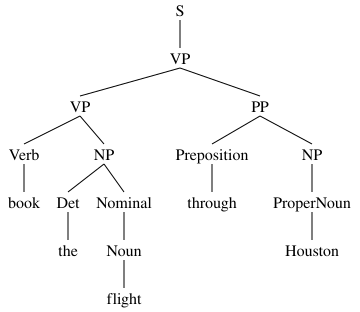


--- Interpretation 2 ---
(S
  (VP
    (Verb book)
    (NP (Det the) (Nominal (Noun flight)))
    (PP (Preposition through) (NP (ProperNoun Houston)))))


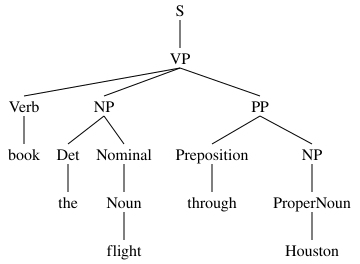


--- Interpretation 3 ---
(S
  (VP
    (Verb book)
    (NP
      (Det the)
      (Nominal
        (Nominal (Noun flight))
        (PP (Preposition through) (NP (ProperNoun Houston)))))))


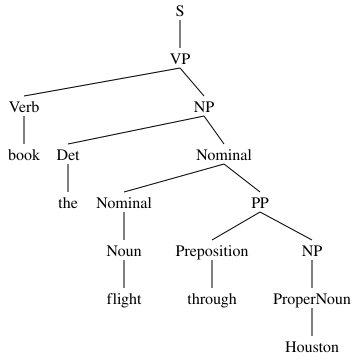

In [44]:
sentence3 = "book the flight through Houston".split()

print("Parsing: ", " ".join(sentence3))
ambiguous_trees = list(atis_parser.parse(sentence3))

print(f"\nFound {len(ambiguous_trees)} valid parse trees!")
for i, tree in enumerate(ambiguous_trees):
    print(f"\n--- Interpretation {i + 1} ---")
    print(tree)
    display(tree)

### Example 5: Treebanks and Real-World Parsing
Writing toy grammars by hand is great for learning, but it is impossible to manually capture all the rules and ambiguities of a natural language like English. 

In the real world, parsers are trained on a **Treebank**—a corpus in which every sentence is annotated with a parse tree by human linguists. The sentences in a treebank implicitly constitute a massive grammar of the language. The most famous example for English is the **Penn Treebank**.

Let's use NLTK to load a sample parsed sentence directly from the Penn Treebank corpus.

In [45]:
# Download the treebank corpus if you haven't already
nltk.download('treebank')
from nltk.corpus import treebank

# Get the parsed tree for the first sentence in the corpus
# "Pierre Vinken, 61 years old, will join the board as a nonexecutive director Nov. 29."
penn_tree = treebank.parsed_sents('wsj_0001.mrg')[0]

print("--- Penn Treebank Parse Tree ---")
print(penn_tree)

# The grammar used to parse the Penn Treebank is very flat, resulting in thousands of rules.
# Let's extract and view the specific CFG rules used just in this single sentence!
print("\n--- Extracted CFG Rules for this sentence ---")
for production in penn_tree.productions()[:10]: # Showing first 10 rules
    print(production)
print("...")

# You can also draw this massive tree
# display(penn_tree)

--- Penn Treebank Parse Tree ---
(S
  (NP-SBJ
    (NP (NNP Pierre) (NNP Vinken))
    (, ,)
    (ADJP (NP (CD 61) (NNS years)) (JJ old))
    (, ,))
  (VP
    (MD will)
    (VP
      (VB join)
      (NP (DT the) (NN board))
      (PP-CLR (IN as) (NP (DT a) (JJ nonexecutive) (NN director)))
      (NP-TMP (NNP Nov.) (CD 29))))
  (. .))

--- Extracted CFG Rules for this sentence ---
S -> NP-SBJ VP .
NP-SBJ -> NP , ADJP ,
NP -> NNP NNP
NNP -> 'Pierre'
NNP -> 'Vinken'
, -> ','
ADJP -> NP JJ
NP -> CD NNS
CD -> '61'
NNS -> 'years'
...


[nltk_data] Downloading package treebank to /home/asamai/nltk_data...
[nltk_data]   Package treebank is already up-to-date!
